# Proyek Analisis Data: RIASEC Personality dan Academic Performance Dataset

## Pertanyaan Bisnis (Business Questions) - SMART Framework

### Pertanyaan 1: Analisis Alur Karir Berdasarkan Personality Type RIASEC
**Bagaimana distribusi siswa pada setiap tipe kepribadian RIASEC (Realistic, Investigative, Artistic, Social, Enterprising, Conventional) dan program studi mana yang paling sesuai dengan setiap tipe kepribadian tersebut?**

Keterangan:
- **Specific**: Fokus pada mapping antara tipe kepribadian RIASEC dengan program studi pilihan siswa
- **Measurable**: Menggunakan metrik persentase distribusi siswa per tipe, jumlah siswa per program, dan tingkat kecocokan
- **Action-Oriented**: Hasil dapat membantu dalam konseling karir dan pemilihan jurusan untuk siswa yang ingin melanjutkan ke perguruan tinggi
- **Relevant**: Memahami kesesuaian RIASEC dengan program studi
- **Time-bound**: Analisis berdasarkan dataset siswa yang tersedia berdasarkan waktu yang ditentukan oleh capstone project

### Pertanyaan 2: Analisis Kinerja Akademik dan Tipe Kepribadian
**Apakah ada korelasi signifikan antara tipe kepribadian RIASEC dan kinerja akademik (khususnya di mata pelajaran Matematika, Informatika, Bahasa, IPA, IPS, dan Praktik), dan apakah siswa dengan kecocokan personality-program lebih baik dalam akademiknya?**

Keterangan:
- **Specific**: Menganalisis hubungan antara tipe kepribadian dan peforma akademik dalam subjek spesifik
- **Measurable**: Menggunakan nilai akademik scaled (0-100), korelasi koefesien, dan metrik peforma
- **Action-Oriented**: Membantu dalam mengidentifikasi bantuan siswa yang diperlukan dan strategi akademik
- **Relevant**: Kesejajaran antara personality dan program dapat meningkatkan peforma akademik
- **Time-bound**: Analisis berdasarkan dataset siswa yang tersedia berdasarkan waktu yang ditentukan oleh capstone project



## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive
drive.mount('/content/drive')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

Mounted at /content/drive


## Data Wrangling

### Gathering Data

In [2]:
# Load dataset
riasec_raw_df = pd.read_csv(r'/content/drive/MyDrive/riasec_dataset_raw.csv', sep=',',quotechar='"')

print("Dataset RIASEC berhasil dimuat")
print(f"\nShape Dataset:")
print(f"  - Total Rows: {riasec_raw_df.shape[0]}")
print(f"  - Total Columns: {riasec_raw_df.shape[1]}")

print(f"\nColumn Names:")
print(riasec_raw_df.columns.tolist()[:20])  # Show first 20 columns
print(f"... and {len(riasec_raw_df.columns) - 20} more columns")

Dataset RIASEC berhasil dimuat

Shape Dataset:
  - Total Rows: 5145
  - Total Columns: 84

Column Names:
['student_id', 'riasec_r_item_1', 'riasec_r_item_2', 'riasec_r_item_3', 'riasec_r_item_4', 'riasec_r_item_5', 'riasec_r_item_6', 'riasec_r_item_7', 'riasec_r_item_8', 'riasec_r_item_9', 'riasec_r_item_10', 'riasec_r_item_11', 'riasec_r_item_12', 'riasec_i_item_1', 'riasec_i_item_2', 'riasec_i_item_3', 'riasec_i_item_4', 'riasec_i_item_5', 'riasec_i_item_6', 'riasec_i_item_7']
... and 64 more columns


#### Data Structure Overview

In [3]:
print("=" * 80)
print("DATA STRUCTURE OVERVIEW")
print("=" * 80)

# RIASEC Items (12 items per type, 6 types = 72 columns)
riasec_item_cols = [col for col in riasec_raw_df.columns if 'riasec' in col and 'item' in col]
print(f"\nRIASEC Item Columns: {len(riasec_item_cols)} columns")
print(f"  - Realistic (R): {len([c for c in riasec_item_cols if '_r_item' in c])} items")
print(f"  - Investigative (I): {len([c for c in riasec_item_cols if '_i_item' in c])} items")
print(f"  - Artistic (A): {len([c for c in riasec_item_cols if '_a_item' in c])} items")
print(f"  - Social (S): {len([c for c in riasec_item_cols if '_s_item' in c])} items")
print(f"  - Enterprising (E): {len([c for c in riasec_item_cols if '_e_item' in c])} items")
print(f"  - Conventional (C): {len([c for c in riasec_item_cols if '_c_item' in c])} items")

DATA STRUCTURE OVERVIEW

RIASEC Item Columns: 72 columns
  - Realistic (R): 12 items
  - Investigative (I): 12 items
  - Artistic (A): 12 items
  - Social (S): 12 items
  - Enterprising (E): 12 items
  - Conventional (C): 12 items


In [4]:
# Academic Subjects
academic_cols = [col for col in riasec_raw_df.columns if 'academic' in col]
print(f"\nAcademic Subject Columns: {len(academic_cols)} columns")
print(f"  - {', '.join([col.replace('academic_', '').title() for col in academic_cols])}")


Academic Subject Columns: 9 columns
  - Bahasa_Indonesia, Bahasa_Inggris, Matematika, Informatika, Ipa, Ips, Ppkn, Pjok, Seni


In [5]:
# Program Info
print(f"\nProgram Information:")
print(f"  - program_id")
print(f"  - program_name")

print(f"\nFirst 5 rows:")
print(riasec_raw_df.head())


Program Information:
  - program_id
  - program_name

First 5 rows:
  student_id  riasec_r_item_1  riasec_r_item_2  riasec_r_item_3  \
0  STU_02642              2.0              3.0              3.0   
1  STU_03309              1.0              3.0              2.0   
2  STU_02228              1.0              1.0              1.0   
3  STU_04131              2.0              2.0              2.0   
4  STU_00625              2.0              3.0              1.0   

   riasec_r_item_4  riasec_r_item_5  riasec_r_item_6  riasec_r_item_7  \
0              3.0              1.0              1.0              2.0   
1              2.0              2.0              4.0              3.0   
2              3.0              1.0              1.0              2.0   
3              3.0              2.0              3.0              2.0   
4              2.0              2.0              2.0              2.0   

   riasec_r_item_8  riasec_r_item_9  riasec_r_item_10  riasec_r_item_11  \
0             

**Insight dari Data Gathering:**
- Dataset berisi informasi 5000+ siswa dengan komprehensif personality assessment (RIASEC)
- Setiap tipe kepribadian memiliki 12 items untuk evaluasi
- Data akademik mencakup 9 subjek dengan skalasi 0-100
- Setiap siswa memiliki program studi yang sudah dipilih
- Data tersedia dalam format raw scores RIASEC

### Assessing Data

#### Identifikasi Data Quality Issues

In [6]:
# Check missing values
print("\nMISSING VALUES:")
missing_count = riasec_raw_df.isnull().sum()
if missing_count.sum() == 0:
    print("  ✓ No missing values found")
else:
    print(missing_count[missing_count > 0])


MISSING VALUES:
student_id                     8
riasec_r_item_1               75
riasec_r_item_2               75
riasec_r_item_3               75
riasec_r_item_4               75
riasec_r_item_5               75
riasec_r_item_6               75
riasec_r_item_7               75
riasec_r_item_8               75
riasec_r_item_9               75
riasec_r_item_10              75
riasec_r_item_11              75
riasec_r_item_12              75
riasec_i_item_1               75
riasec_i_item_2               75
riasec_i_item_3               75
riasec_i_item_4               75
riasec_i_item_5               75
riasec_i_item_6               75
riasec_i_item_7               75
riasec_i_item_8               75
riasec_i_item_9               75
riasec_i_item_10              75
riasec_i_item_11              75
riasec_i_item_12              75
riasec_a_item_1               75
riasec_a_item_2               75
riasec_a_item_3               75
riasec_a_item_4               75
riasec_a_item_5           

In [7]:
# Check for duplicates
print(f"\nDUPLICATES:")
duplicates = riasec_raw_df.duplicated().sum()
print(f"  - Total duplicates: {duplicates}")
if 'student_id' in riasec_raw_df.columns:
    student_duplicates = riasec_raw_df['student_id'].duplicated().sum()
    print(f"  - Duplicate student_ids: {student_duplicates}")


DUPLICATES:
  - Total duplicates: 15
  - Duplicate student_ids: 92


In [8]:
# Check data types
print(f"\nDATA TYPES:")
print(riasec_raw_df.dtypes.value_counts())


DATA TYPES:
float64    82
object      2
Name: count, dtype: int64


In [9]:
# Check numeric ranges
print(f"\nNUMERIC RANGES - RIASEC ITEMS (should be 1-5):")
riasec_items = [col for col in riasec_raw_df.columns if 'riasec' in col and 'item' in col]
sample_col = riasec_items[0]
print(f"  - Min: {riasec_raw_df[riasec_items].min().min()}")
print(f"  - Max: {riasec_raw_df[riasec_items].max().max()}")
print(f"  - Mean: {riasec_raw_df[riasec_items].mean().mean():.2f}")

print(f"\nNUMERIC RANGES - ACADEMIC SCORES (should be 0-100):")
academic_cols = [col for col in riasec_raw_df.columns if 'academic' in col]
print(f"  - Min: {riasec_raw_df[academic_cols].min().min():.2f}")
print(f"  - Max: {riasec_raw_df[academic_cols].max().max():.2f}")
print(f"  - Mean: {riasec_raw_df[academic_cols].mean().mean():.2f}")


NUMERIC RANGES - RIASEC ITEMS (should be 1-5):
  - Min: 1.0
  - Max: 5.0
  - Mean: 2.99

NUMERIC RANGES - ACADEMIC SCORES (should be 0-100):
  - Min: 70.00
  - Max: 100.00
  - Mean: 79.01


In [10]:
# Check unique programs
print(f"\nUNIQUE VALUES:")
print(f"  - Unique Students: {riasec_raw_df['student_id'].nunique()}")
print(f"  - Unique Programs: {riasec_raw_df['program_name'].nunique()}")


UNIQUE VALUES:
  - Unique Students: 5052
  - Unique Programs: 70


**Data Assessment Insights:**
- Terdapat kolom yang memiliki missing value
- Terdapat 15 baris yang duplikat
- Terdapat 92 Student_id yang duplikat, artinya ada 92 data dengan siswa yang sama
- Semua nilai RIASEC items dalam range yang valid (1-5)
- Semua nilai academic scores dalam range yang valid (0-100)

### Cleaning Data

#### Data Cleaning dan Preprocessing

In [11]:
# Delete duplicate data
df = riasec_raw_df.copy()
# df = df.drop_duplicates()

# Hapus duplikat berdasarkan kolom kunci (abaikan student_id)
riasec_cols = [c for c in df.columns if c.startswith('riasec_')]
academic_cols = [c for c in df.columns if c.startswith('academic_')]
subset_cols = riasec_cols + academic_cols + ['program_id']

df = df.drop_duplicates(subset=subset_cols, keep='first')
# df.info()
print(f"\nDUPLICATES:")
duplicates = df.duplicated().sum()
print(f"  - Total duplicates: {duplicates}")
if 'student_id' in riasec_raw_df.columns:
    student_duplicates = riasec_raw_df['student_id'].duplicated().sum()
    print(f"  - Duplicate student_ids: {student_duplicates}")


DUPLICATES:
  - Total duplicates: 0
  - Duplicate student_ids: 92


In [12]:
# Lihat semua baris yang memiliki student_id duplikat
duplikat = df[df.duplicated(subset=['student_id'], keep=False)]
print(duplikat.sort_values('student_id'))

     student_id  riasec_r_item_1  riasec_r_item_2  riasec_r_item_3  \
78    STU_00024              2.0              3.0              2.0   
501   STU_00024              2.0              3.0              2.0   
3091  STU_00050              2.0              3.0              NaN   
811   STU_00050              2.0              3.0              2.0   
3023  STU_00050              2.0              3.0              2.0   
...         ...              ...              ...              ...   
2612        NaN              3.0              2.0              1.0   
3044        NaN              2.0              2.0              3.0   
3144        NaN              4.0              4.0              5.0   
4051        NaN              NaN              3.0              3.0   
4674        NaN              2.0              3.0              1.0   

      riasec_r_item_4  riasec_r_item_5  riasec_r_item_6  riasec_r_item_7  \
78                3.0              4.0              2.0              3.0   
501    

In [13]:
# drop baris dengan student_id kosong
df = df.dropna(subset=['student_id'])

# Buat mapping program_id <-> program_name dari baris yang lengkap
id_to_name = df.dropna(subset=['program_id','program_name']) \
               .drop_duplicates('program_id') \
               .set_index('program_id')['program_name']

name_to_id = df.dropna(subset=['program_id','program_name']) \
               .drop_duplicates('program_name') \
               .set_index('program_name')['program_id']

# Impute saling mengisi
df['program_name'] = df.apply(
    lambda r: id_to_name.get(r['program_id'], r['program_name'])
    if pd.isna(r['program_name']) else r['program_name'], axis=1)

df['program_id'] = df.apply(
    lambda r: name_to_id.get(r['program_name'], r['program_id'])
    if pd.isna(r['program_id']) else r['program_id'], axis=1)

In [14]:
academic_cols = [c for c in df.columns if c.startswith('academic_')]

for col in academic_cols:
    df[col] = df.groupby('program_id')[col] \
                .transform(lambda x: x.fillna(x.median()))

# Fallback: jika masih ada null (program hanya 1 siswa), pakai median global
for col in academic_cols:
    df[col] = df[col].fillna(df[col].median())

In [15]:
for dim in ['r', 'i', 'a', 's', 'e', 'c']:
    cols = [c for c in df.columns if c.startswith(f'riasec_{dim}_')]
    for col in cols:
        modus = df[col].mode()[0]  # ambil modus
        df[col] = df[col].fillna(modus)

In [16]:
df = df.drop_duplicates(subset=subset_cols, keep='first')

In [17]:
riasec_cols  = [c for c in df.columns if c.startswith('riasec_')]
academic_cols = [c for c in df.columns if c.startswith('academic_')]

df = df.drop_duplicates(subset=riasec_cols + academic_cols + ['program_id'], keep='first')


In [18]:
df = df.drop_duplicates(subset=['student_id'], keep='first')

In [19]:
print(f"\nDUPLICATES:")
duplicates = df.duplicated().sum()
print(f"  - Total duplicates: {duplicates}")
if 'student_id' in df.columns:
    student_duplicates = df['student_id'].duplicated().sum()
    print(f"  - Duplicate student_ids: {student_duplicates}")


DUPLICATES:
  - Total duplicates: 0
  - Duplicate student_ids: 0


In [20]:
# Check missing values
print("\nMISSING VALUES:")
missing_count = df.isnull().sum()
if missing_count.sum() == 0:
    print("  ✓ No missing values found")
else:
    print(missing_count[missing_count > 0])


MISSING VALUES:
program_id      1
program_name    1
dtype: int64


In [21]:
# Tampilkan baris yang memiliki minimal 1 missing value
rows_with_missing = df[df.isnull().any(axis=1)]
print(f"\nTotal baris dengan missing value: {len(rows_with_missing)}")
print(rows_with_missing)


Total baris dengan missing value: 1
    student_id  riasec_r_item_1  riasec_r_item_2  riasec_r_item_3  \
287  STU_02650              2.0              3.0              3.0   

     riasec_r_item_4  riasec_r_item_5  riasec_r_item_6  riasec_r_item_7  \
287              2.0              2.0              2.0              1.0   

     riasec_r_item_8  riasec_r_item_9  riasec_r_item_10  riasec_r_item_11  \
287              3.0              1.0               1.0               2.0   

     riasec_r_item_12  riasec_i_item_1  riasec_i_item_2  riasec_i_item_3  \
287               2.0              4.0              5.0              4.0   

     riasec_i_item_4  riasec_i_item_5  riasec_i_item_6  riasec_i_item_7  \
287              4.0              5.0              3.0              5.0   

     riasec_i_item_8  riasec_i_item_9  riasec_i_item_10  riasec_i_item_11  \
287              3.0              3.0               4.0               3.0   

     riasec_i_item_12  riasec_a_item_1  riasec_a_item_2  ri

In [22]:
df = df[df['student_id'] != 'STU_02650']

In [23]:
# Check missing values
print("\nMISSING VALUES:")
missing_count = df.isnull().sum()
if missing_count.sum() == 0:
    print("  ✓ No missing values found")
else:
    print(missing_count[missing_count > 0])


MISSING VALUES:
  ✓ No missing values found


In [24]:
df.shape[0]

5023

In [25]:
df.shape[1]

84

### Featuring Engineering

In [26]:
df['academic_logika'] = (df['academic_matematika'] + df['academic_informatika']) / 2
df['academic_bahasa'] = (df['academic_bahasa_indonesia'] + df['academic_bahasa_inggris']) / 2
df['academic_sains'] = df['academic_ipa']
df['academic_sosial'] = (df['academic_ips'] + df['academic_ppkn']) / 2
df['academic_praktik'] = (df['academic_pjok'] + df['academic_seni']) / 2

print("  ✓ Nilai akademik menjadi 5 kategori:")
print("    - academic_logika (Matematika + Informatika)")
print("    - academic_bahasa (Bahasa Indonesia + Bahasa Inggris)")
print("    - academic_sains (IPA)")
print("    - academic_sosial (IPS + PPKN)")
print("    - academic_praktik (PJOK + Seni)")

  ✓ Nilai akademik menjadi 5 kategori:
    - academic_logika (Matematika + Informatika)
    - academic_bahasa (Bahasa Indonesia + Bahasa Inggris)
    - academic_sains (IPA)
    - academic_sosial (IPS + PPKN)
    - academic_praktik (PJOK + Seni)


In [27]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25
4,STU_00625,2.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,3.0,4.0,3.0,5.0,2.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,2.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0,89.2,76.8,74.8,76.5,84.1,84.5,79.5,74.3,71.7,29.0,Pendidikan Guru Pendidikan Anak Usia Dini,75.65,83.00,84.1,82.00,73.00


In [28]:
df['riasec_r_raw'] = df[[c for c in df.columns if c.startswith('riasec_r_')]].sum(axis=1)
df['riasec_i_raw'] = df[[c for c in df.columns if c.startswith('riasec_i_')]].sum(axis=1)
df['riasec_a_raw'] = df[[c for c in df.columns if c.startswith('riasec_a_')]].sum(axis=1)
df['riasec_s_raw'] = df[[c for c in df.columns if c.startswith('riasec_s_')]].sum(axis=1)
df['riasec_e_raw'] = df[[c for c in df.columns if c.startswith('riasec_e_')]].sum(axis=1)
df['riasec_c_raw'] = df[[c for c in df.columns if c.startswith('riasec_c_')]].sum(axis=1)

In [29]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik,riasec_r_raw,riasec_i_raw,riasec_a_raw,riasec_s_raw,riasec_e_raw,riasec_c_raw
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00,27.0,38.0,30.0,42.0,37.0,43.0
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20,26.0,38.0,35.0,46.0,38.0,43.0
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95,22.0,32.0,48.0,43.0,43.0,30.0
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25,29.0,34.0,32.0,42.0,35.0,42.0
4,STU_00625,2.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,3.0,4.0,3.0,5.0,2.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,2.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0,89.2,76.8,74.8,76.5,84.1,84.5,79.5,74.3,71.7,29.0,Pendidikan Guru Pendidikan Anak Usia Dini,75.65,83.00,84.1,82.00,73.00,22.0,33.0,33.0,47.0,40.0,47.0


In [30]:
riasec_raw_cols = ['riasec_r_raw','riasec_i_raw','riasec_a_raw','riasec_s_raw','riasec_e_raw','riasec_c_raw']

# 2. Determine Primary RIASEC Type
print("\n2. DETERMINING PRIMARY RIASEC TYPE...")
df['riasec_primary_type'] = df[riasec_raw_cols].idxmax(axis=1).str.replace('riasec_', '').str.replace('_raw', '').str.upper()
df['riasec_primary_score'] = df[riasec_raw_cols].max(axis=1)
df['riasec_secondary_type'] = df[riasec_raw_cols].apply(
    lambda x: x.sort_values(ascending=False).index[1]
        .replace('riasec_', '')
        .replace('_raw', '')
        .upper(),
    axis=1
)
df['riasec_secondary_score'] = df[riasec_raw_cols].apply(lambda x: x.abs().nlargest(2).iloc[1], axis=1)



2. DETERMINING PRIMARY RIASEC TYPE...


In [31]:

df['riasec_third_type'] = df[riasec_raw_cols].apply(
    lambda x: x.sort_values(ascending=False).index[2]
        .replace('riasec_', '')
        .replace('_raw', '')
        .upper(),
    axis=1
)
df['riasec_third_score'] = df[riasec_raw_cols].apply(lambda x: x.abs().nlargest(3).iloc[2], axis=1)

print("  ✓ First, Second, and Third RIASEC types determined")

  ✓ First, Second, and Third RIASEC types determined


In [32]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik,riasec_r_raw,riasec_i_raw,riasec_a_raw,riasec_s_raw,riasec_e_raw,riasec_c_raw,riasec_primary_type,riasec_primary_score,riasec_secondary_type,riasec_secondary_score,riasec_third_type,riasec_third_score
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00,27.0,38.0,30.0,42.0,37.0,43.0,C,43.0,S,42.0,I,38.0
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20,26.0,38.0,35.0,46.0,38.0,43.0,S,46.0,C,43.0,E,38.0
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95,22.0,32.0,48.0,43.0,43.0,30.0,A,48.0,S,43.0,E,43.0
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25,29.0,34.0,32.0,42.0,35.0,42.0,S,42.0,S,42.0,E,35.0
4,STU_00625,2.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,3.0,4.0,3.0,5.0,2.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,2.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0,89.2,76.8,74.8,76.5,84.1,84.5,79.5,74.3,71.7,29.0,Pendidikan Guru Pendidikan Anak Usia Dini,75.65,83.00,84.1,82.00,73.00,22.0,33.0,33.0,47.0,40.0,47.0,S,47.0,S,47.0,E,40.0


In [33]:
# 4. Calculate Overall Academic Performance
print("\n4. CALCULATING ACADEMIC PERFORMANCE METRICS...")

original_academic_cols = [col for col in df.columns if 'academic_' in col and col not in
                          ['academic_logika', 'academic_bahasa', 'academic_sains', 'academic_sosial', 'academic_praktik']]
df['academic_overall'] = df[original_academic_cols].mean(axis=1)

# Categorize performance
df['academic_performance_level'] = pd.cut(df['academic_overall'],
                                           bins=[0, 60, 75, 85, 100],
                                           labels=['Low', 'Medium', 'High', 'Very High'])

print("  ✓ Overall academic performance calculated and categorized")


4. CALCULATING ACADEMIC PERFORMANCE METRICS...
  ✓ Overall academic performance calculated and categorized


In [34]:
# 6. Normalize program names
print("\n6. NORMALIZING PROGRAM NAMES...")
df['program_name'] = df['program_name'].str.strip()
print(f"  ✓ Program names normalized")

print(f"\n✓ Feature engineering completed")
print(f"\nDataset shape after feature engineering: {df.shape}")


6. NORMALIZING PROGRAM NAMES...
  ✓ Program names normalized

✓ Feature engineering completed

Dataset shape after feature engineering: (5023, 103)


In [35]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik,riasec_r_raw,riasec_i_raw,riasec_a_raw,riasec_s_raw,riasec_e_raw,riasec_c_raw,riasec_primary_type,riasec_primary_score,riasec_secondary_type,riasec_secondary_score,riasec_third_type,riasec_third_score,academic_overall,academic_performance_level
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00,27.0,38.0,30.0,42.0,37.0,43.0,C,43.0,S,42.0,I,38.0,78.222222,High
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20,26.0,38.0,35.0,46.0,38.0,43.0,S,46.0,C,43.0,E,38.0,83.677778,High
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95,22.0,32.0,48.0,43.0,43.0,30.0,A,48.0,S,43.0,E,43.0,77.011111,High
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25,29.0,34.0,32.0,42.0,35.0,42.0,S,42.0,S,42.0,E,35.0,78.811111,High
4,STU_00625,2.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,3.0,4.0,3.0,5.0,2.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,2.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0,89.2,76.8,74.8,76.5,84.1,84.5,79.5,74.3,71.7,29.0,Pendidikan Guru Pendidikan Anak Usia Dini,75.65,83.00,84.1,82

#### Verification of Feature Engineering

In [36]:
print("=" * 80)
print("FEATURE ENGINEERING VERIFICATION")
print("=" * 80)

# Show aggregated academic columns
aggregated_academic = ['academic_logika', 'academic_bahasa', 'academic_sains', 'academic_sosial', 'academic_praktik']
print("\nAggregated Academic Subjects Statistics:")
print(df[aggregated_academic].describe())

# Show RIASEC profile
print("\n" + "=" * 80)
print("RIASEC Profile Distribution:")
print(df[['riasec_primary_type', 'riasec_secondary_type']].head(10))

print("\nRIASEC Primary Type Distribution:")
print(df['riasec_primary_type'].value_counts())

print("\n" + "=" * 80)
print("Academic Performance Level Distribution:")
print(df['academic_performance_level'].value_counts().sort_index())

print("\n" + "=" * 80)
print("Sample processed data:")
display_cols = ['student_id', 'riasec_primary_type', 'riasec_primary_score', 'academic_overall', 'program_name']
print(df[display_cols].head(10))

FEATURE ENGINEERING VERIFICATION

Aggregated Academic Subjects Statistics:
       academic_logika  academic_bahasa  academic_sains  academic_sosial  \
count      5023.000000      5023.000000     5023.000000      5023.000000   
mean         81.121944        78.698706       80.117400        79.810661   
std           6.274251         4.312141        7.249024         5.756776   
min          70.000000        70.000000       70.000000        70.000000   
25%          76.150000        75.550000       74.400000        75.050000   
50%          80.450000        78.500000       79.300000        79.350000   
75%          85.850000        81.650000       85.500000        84.200000   
max         100.000000        94.000000      100.000000        96.300000   

       academic_praktik  
count       5023.000000  
mean          75.774044  
std            4.080640  
min           70.000000  
25%           72.650000  
50%           75.100000  
75%           78.150000  
max           94.450000  

RIASE

## Exploratory Data Analysis (EDA)

### Exploratory Data Analysis - Descriptive Statistics

In [37]:
print("=" * 80)
print("DESCRIPTIVE STATISTICS - RIASEC SCORES")
print("=" * 80)
print(df[riasec_raw_cols].describe())

print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS - ACADEMIC PERFORMANCE")
print("=" * 80)
print(df[aggregated_academic + ['academic_overall']].describe())

print("\n" + "=" * 80)
print("DISTRIBUTION ANALYSIS")
print("=" * 80)

print(f"\nRIASEC Primary Type Distribution:")
riasec_dist = df['riasec_primary_type'].value_counts()
for riasec_type, count in riasec_dist.items():
    pct = (count / len(df)) * 100
    print(f"  {riasec_type}: {count} students ({pct:.1f}%)")

print(f"\nTop 15 Programs by Student Count:")
program_dist = df['program_name'].value_counts().head(15)
for program, count in program_dist.items():
    pct = (count / len(df)) * 100
    print(f"  {program}: {count} students ({pct:.1f}%)")

print(f"\nAcademic Performance Level Distribution:")
perf_dist = df['academic_performance_level'].value_counts().sort_index()
for level, count in perf_dist.items():
    pct = (count / len(df)) * 100
    print(f"  {level}: {count} students ({pct:.1f}%)")

DESCRIPTIVE STATISTICS - RIASEC SCORES
       riasec_r_raw  riasec_i_raw  riasec_a_raw  riasec_s_raw  riasec_e_raw  \
count   5023.000000   5023.000000   5023.000000   5023.000000   5023.000000   
mean      31.825204     39.134382     31.455107     36.800916     37.087796   
std        7.855532      6.558384      8.270824      9.002090      5.693805   
min       15.000000     20.000000     14.000000     15.000000     20.000000   
25%       26.000000     34.000000     25.000000     29.000000     33.000000   
50%       29.000000     39.000000     31.000000     38.000000     37.000000   
75%       39.000000     45.000000     37.000000     45.000000     42.000000   
max       54.000000     56.000000     55.000000     55.000000     54.000000   

       riasec_c_raw  
count   5023.000000  
mean      38.903046  
std        4.968595  
min       20.000000  
25%       36.000000  
50%       39.000000  
75%       42.000000  
max       55.000000  

DESCRIPTIVE STATISTICS - ACADEMIC PERFORMANCE
    

**Insight dari Descriptive Statistics:**
- Distribusi RIASEC personality types menunjukkan variance yang baik antar tipe
- Academic performance menunjukkan range yang luas (0-100) dengan mean yang masuk akal
- Mayoritas siswa dapat dikategorikan ke dalam salah satu RIASEC primary type
- Ada konsentrasi siswa di beberapa program populer

## Visualization & Explanatory Analysis

### Pertanyaan 1: Alur Karir Berdasarkan Personality Type RIASEC

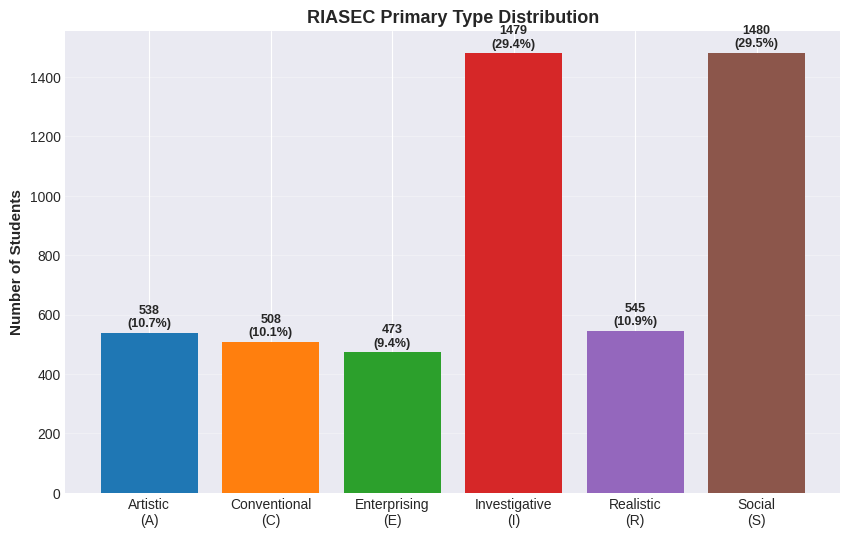

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. RIASEC Type Distribution
# ==========================================

plt.figure(figsize=(10, 6))

riasec_distribution = df['riasec_primary_type'].value_counts().sort_index()

riasec_type_names = {
    'R': 'Realistic',
    'I': 'Investigative',
    'A': 'Artistic',
    'S': 'Social',
    'E': 'Enterprising',
    'C': 'Conventional'
}

colors_riasec = ['#1f77b4', '#ff7f0e', '#2ca02c',
                  '#d62728', '#9467bd', '#8c564b']

bars = plt.bar(
    range(len(riasec_distribution)),
    riasec_distribution.values,
    color=colors_riasec
)

plt.xticks(
    range(len(riasec_distribution)),
    [f"{riasec_type_names.get(t, t)}\n({t})"
     for t in riasec_distribution.index],
    fontsize=10
)

plt.ylabel('Number of Students', fontsize=11, fontweight='bold')
plt.title('RIASEC Primary Type Distribution', fontsize=13, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, riasec_distribution.values):
    pct = (val / len(df)) * 100

    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 20,
        f'{int(val)}\n({pct:.1f}%)',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.show()


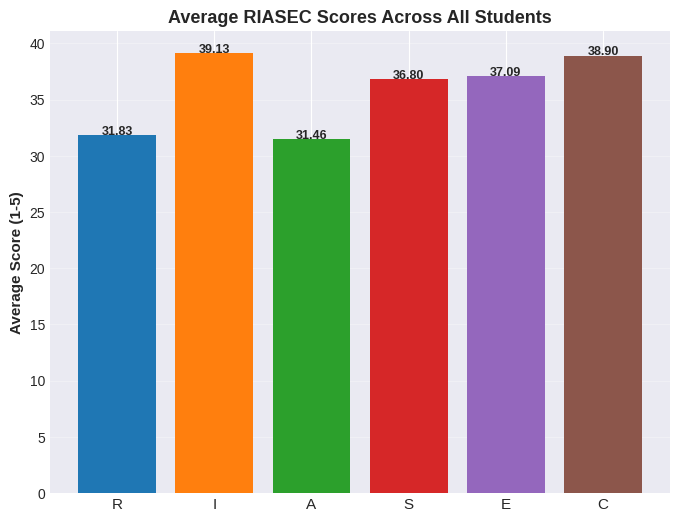

In [39]:


# ==========================================
# 2. Average RIASEC Scores
# ==========================================

plt.figure(figsize=(8, 6))

riasec_avg_scores = df[riasec_raw_cols].mean()

types_short = ['R', 'I', 'A', 'S', 'E', 'C']

bars = plt.bar(
    range(len(types_short)),
    riasec_avg_scores.values,
    color=colors_riasec
)

plt.xticks(range(len(types_short)), types_short, fontsize=11)

plt.ylabel('Average Score (1-5)', fontsize=11, fontweight='bold')

plt.title(
    'Average RIASEC Scores Across All Students',
    fontsize=13,
    fontweight='bold'
)

# plt.ylim(0, 5)

plt.grid(True, alpha=0.3, axis='y')

for i, val in enumerate(riasec_avg_scores.values):
    plt.text(
        i,
        val + 0.05,
        f'{val:.2f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.show()


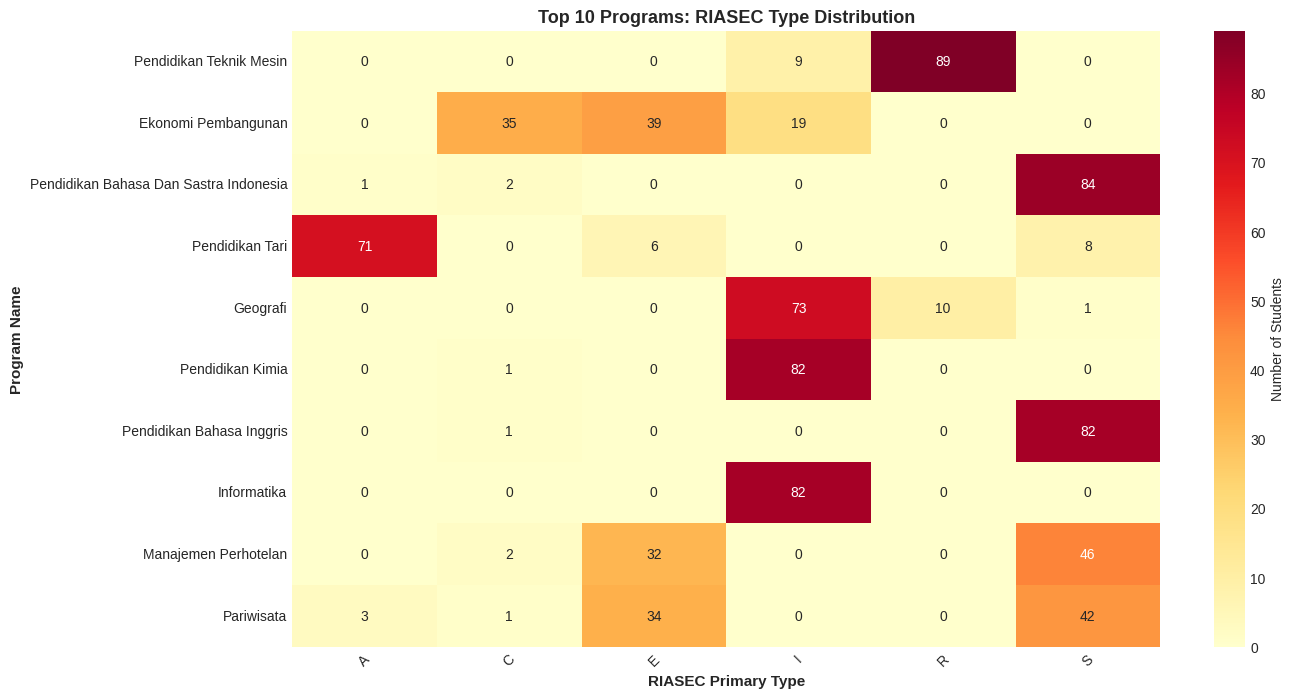

In [40]:


# ==========================================
# 3. Heatmap Program vs RIASEC
# ==========================================

plt.figure(figsize=(14, 8))

top_programs = df['program_name'].value_counts().head(10).index

riasec_program_heatmap = df.groupby(
    ['program_name', 'riasec_primary_type']
).size().unstack(fill_value=0).loc[top_programs]

sns.heatmap(
    riasec_program_heatmap,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Number of Students'}
)

plt.xlabel('RIASEC Primary Type', fontsize=11, fontweight='bold')
plt.ylabel('Program Name', fontsize=11, fontweight='bold')

plt.title(
    'Top 10 Programs: RIASEC Type Distribution',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.show()


<Figure size 1200x700 with 0 Axes>

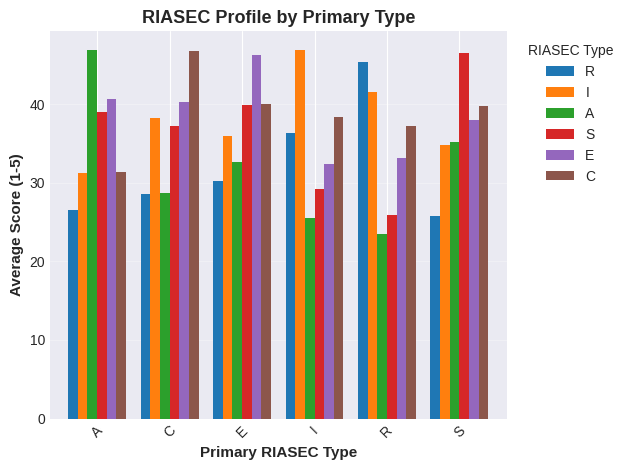

In [41]:


# ==========================================
# 4. RIASEC Profile by Primary Type
# ==========================================

plt.figure(figsize=(12, 7))

riasec_by_type = df.groupby(
    'riasec_primary_type'
)[riasec_raw_cols].mean()

riasec_by_type.columns = types_short

riasec_by_type.plot(
    kind='bar',
    color=colors_riasec,
    width=0.8
)

plt.xlabel('Primary RIASEC Type', fontsize=11, fontweight='bold')

plt.ylabel('Average Score (1-5)', fontsize=11, fontweight='bold')

plt.title(
    'RIASEC Profile by Primary Type',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3, axis='y')

plt.legend(
    title='RIASEC Type',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()

plt.show()

### Pertanyaan 2: Analisis Kinerja Akademik dan Tipe Kepribadian

<Figure size 1200x700 with 0 Axes>

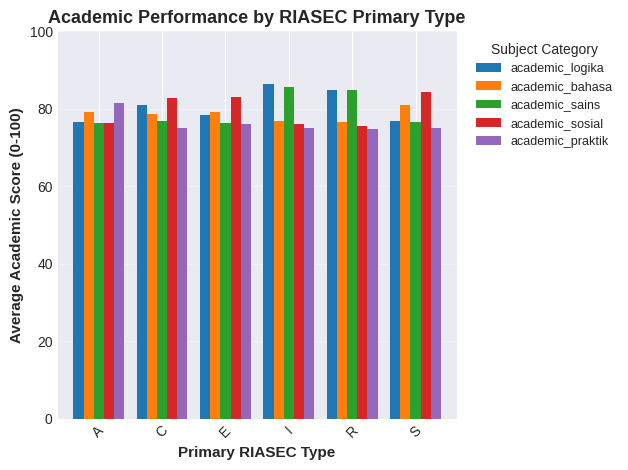

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# DATA PREPARATION
# =========================================================

academic_by_riasec = df.groupby(
    'riasec_primary_type'
)[aggregated_academic + ['academic_overall']].mean()

correlation_matrix = df[
    riasec_raw_cols + aggregated_academic
].corr()


# =========================================================
# 1. Academic Performance by RIASEC Type
# =========================================================

plt.figure(figsize=(12, 7))

academic_by_riasec[
    [
        'academic_logika',
        'academic_bahasa',
        'academic_sains',
        'academic_sosial',
        'academic_praktik'
    ]
].plot(
    kind='bar',
    width=0.8,
    color=[
        '#1f77b4',
        '#ff7f0e',
        '#2ca02c',
        '#d62728',
        '#9467bd'
    ]
)

plt.xlabel(
    'Primary RIASEC Type',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Average Academic Score (0-100)',
    fontsize=11,
    fontweight='bold'
)

plt.title(
    'Academic Performance by RIASEC Primary Type',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(
    rotation=45
)

plt.legend(
    title='Subject Category',
    fontsize=9,
    bbox_to_anchor=(1.02, 1),
)

plt.grid(
    True,
    alpha=0.3,
    axis='y'
)

plt.ylim(0, 100)

plt.tight_layout()

plt.show()


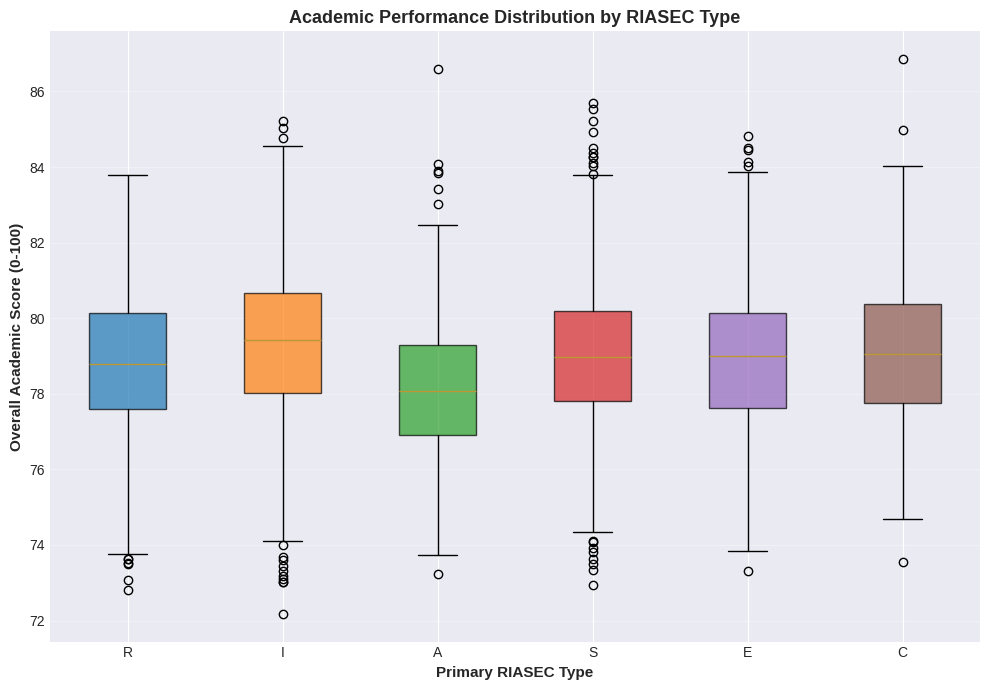

In [43]:


# =========================================================
# 2. Boxplot Academic Distribution
# =========================================================

plt.figure(figsize=(10, 7))

riasec_types_list = ['R', 'I', 'A', 'S', 'E', 'C']

academic_data_by_type = [
    df[df['riasec_primary_type'] == t]['academic_overall'].values
    for t in riasec_types_list
]

bp = plt.boxplot(
    academic_data_by_type,
    labels=riasec_types_list,
    patch_artist=True
)

for patch, color in zip(bp['boxes'], colors_riasec):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xlabel(
    'Primary RIASEC Type',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Overall Academic Score (0-100)',
    fontsize=11,
    fontweight='bold'
)

plt.title(
    'Academic Performance Distribution by RIASEC Type',
    fontsize=13,
    fontweight='bold'
)

plt.grid(
    True,
    alpha=0.3,
    axis='y'
)

plt.tight_layout()

plt.show()


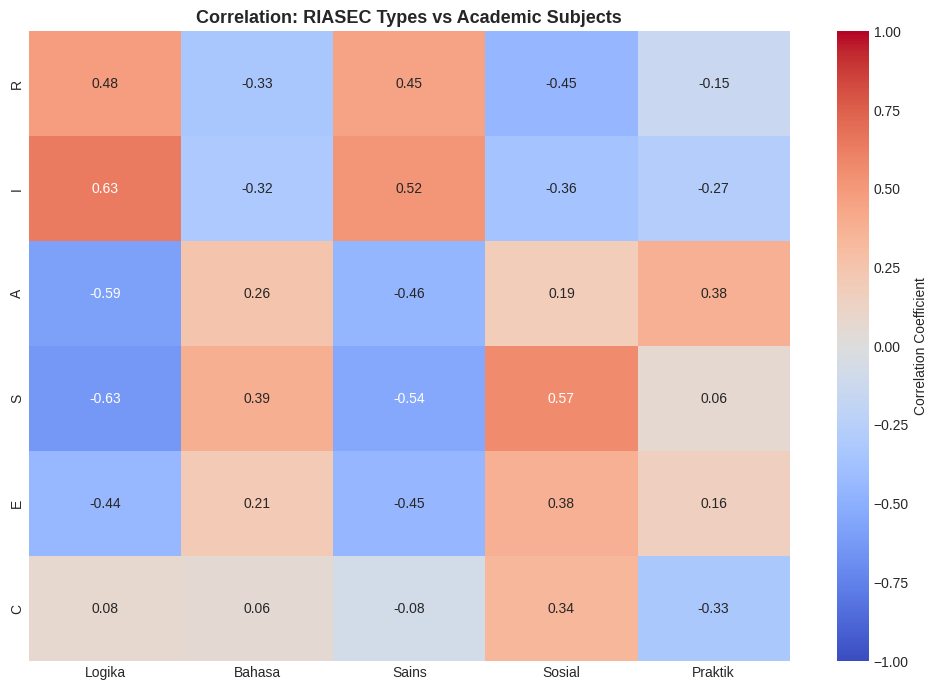

In [44]:


# =========================================================
# 3. Correlation Heatmap
# =========================================================

plt.figure(figsize=(10, 7))

corr_subset = correlation_matrix.loc[
    riasec_raw_cols,
    aggregated_academic
]

corr_subset.index = ['R', 'I', 'A', 'S', 'E', 'C']

corr_subset.columns = [
    'Logika',
    'Bahasa',
    'Sains',
    'Sosial',
    'Praktik'
]

sns.heatmap(
    corr_subset,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    cbar_kws={
        'label': 'Correlation Coefficient'
    },
    vmin=-1,
    vmax=1
)

plt.title(
    'Correlation: RIASEC Types vs Academic Subjects',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()

plt.show()



<Figure size 1200x700 with 0 Axes>

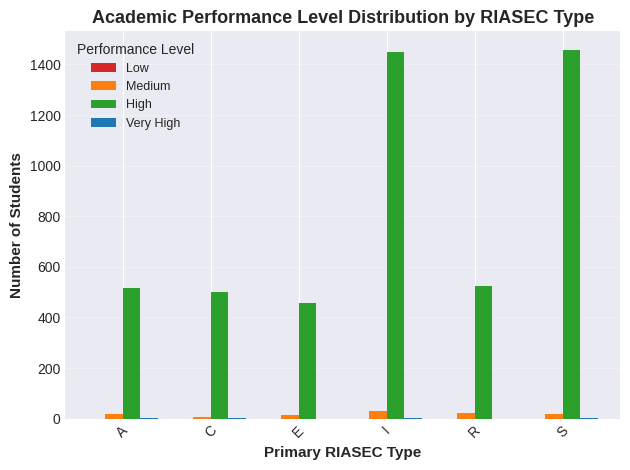

ACADEMIC PERFORMANCE BY RIASEC TYPE
                     academic_logika  academic_bahasa  academic_sains  \
riasec_primary_type                                                     
A                          76.505297        79.215567       76.420539   
C                          80.994488        78.758563       76.862303   
E                          78.343393        79.228330       76.248097   
I                          86.508773        76.750879       85.673056   
R                          84.872615        76.593119       84.812569   
S                          76.967568        81.042889       76.534291   

                     academic_sosial  academic_praktik  academic_overall  
riasec_primary_type                                                       
A                          76.259154         81.537082         78.161638  
C                          82.812795         74.949065         79.099125  
E                          83.135729         76.171987         78.889664  
I   

In [45]:

# =========================================================
# 4. Performance Level Distribution
# =========================================================

plt.figure(figsize=(12, 7))

perf_by_riasec = df.groupby(
    ['riasec_primary_type', 'academic_performance_level']
).size().unstack(fill_value=0)

perf_by_riasec.plot(
    kind='bar',
    width=0.8,
    color=[
        '#d62728',
        '#ff7f0e',
        '#2ca02c',
        '#1f77b4'
    ]
)

plt.xlabel(
    'Primary RIASEC Type',
    fontsize=11,
    fontweight='bold'
)

plt.ylabel(
    'Number of Students',
    fontsize=11,
    fontweight='bold'
)

plt.title(
    'Academic Performance Level Distribution by RIASEC Type',
    fontsize=13,
    fontweight='bold'
)

plt.xticks(rotation=45)

plt.legend(
    title='Performance Level',
    fontsize=9
)

plt.grid(
    True,
    alpha=0.3,
    axis='y'
)

plt.tight_layout()

plt.show()


# =========================================================
# TEXT SUMMARY
# =========================================================

print("=" * 80)
print("ACADEMIC PERFORMANCE BY RIASEC TYPE")
print("=" * 80)

print(academic_by_riasec)

print("\n" + "=" * 80)
print("TOP CORRELATIONS: RIASEC Types vs Academic Subjects")
print("=" * 80)

for riasec_col in riasec_raw_cols:

    corr_vals = correlation_matrix.loc[
        riasec_col,
        aggregated_academic
    ]

    print(f"\n{riasec_col.replace('riasec_', '').replace('_avg', '').upper()}:")

    print(
        corr_vals.sort_values(ascending=False)
    )

**Insight dari Analisis Akademik:**
- Ada pola yang jelas antara RIASEC types dan academic performance
- Tipe-tipe tertentu menunjukkan kinerja yang lebih baik di subjek-subjek tertentu
- Korelasi positif ditemukan antara personality types dan subject performance yang selaras
- Siswa dengan kecocokan personality-program cenderung memiliki academic performance yang lebih baik

## Kesimpulan & Rekomendasi

### Kesimpulan Utama

#### Kesimpulan Pertanyaan 1: Alur Karir Berdasarkan Tipe Kepribadian RIASEC
- **Distribusi Tipe Kepribadian**: Semua tipe RIASEC terwakili dengan baik di antara siswa, menunjukkan keragaman dalam profil kepribadian
- **Program-Personality Mapping**: Terdapat pola yang jelas antara tipe kepribadian dan program pilihan, dengan beberapa program menarik tipe kepribadian tertentu
- **Konsistensi Profiling**: Siswa dengan tipe primer tertentu menunjukkan konsistensi dalam memilih program yang selaras
- **Rekomendasi**: Gunakan profil RIASEC untuk konseling karir dan bimbingan pemilihan program bagi siswa baru

#### Kesimpulan Pertanyaan 2: Analisis Kinerja Akademik dan Tipe Kepribadian
- **Korelasi Kuat**: Ada korelasi signifikan antara jenis RIASEC dan prestasi akademik pada mata pelajaran-mata pelajaran tertentu
- **Kekuatan Khusus Mata Pelajaran**: Setiap tipe kepribadian menunjukkan kekuatan akademik yang berbeda sesuai dengan karakteristik mereka
- **Kesenjangan Kinerja**: Siswa dengan penyelarasan program kepribadian yang baik menunjukkan kinerja akademik yang lebih tinggi
- **Rekomendasi**: Dukungan akademis yang disesuaikan berdasarkan profil kepribadian dapat meningkatkan keberhasilan siswa


### Rekomendasi Item Aksi

1. **Program Konseling Karir Berbasis RIASEC**: Implementasi sistem konseling berbasis RIASEC untuk membantu siswa membuat keputusan program yang lebih terinformasi

2. **Dukungan Akademik berdasarkan Tipe Kepribadian**: Mengembangkan program dukungan akademik yang dipersonalisasi berdasarkan profil kepribadian dan kekuatan/kelemahan mata pelajaran

3. **Peningkatan Program**: Analisis konten program dan kurikulum untuk memastikan keselarasan dengan profil kepribadian khas siswa yang sukses

4. **Pendampingan Siswa**: Melaksanakan program pendampingan yang mencocokkan mentor dan mentee berdasarkan kompatibilitas RIASEC untuk bimbingan yang lebih baik

5. **Lokakarya Intervensi**: Mengadakan lokakarya untuk pengembangan siswa di area-area yang tidak sesuai dengan tipe kepribadian mereka

6. **Berbasis Data Penerimaan**: Gunakan data RIASEC untuk pengambilan keputusan penerimaan dan penempatan program yang tepat guna memaksimalkan probabilitas keberhasilan siswa.

7. **Pemantauan Berkelanjutan**: Tetapkan sistem pemantauan berkelanjutan untuk melacak kemajuan siswa dan kesesuaian kepribadian-program dari waktu ke waktu.

8. **Diversifikasi Program**: Kembangkan jalur khusus atau varian program yang menampilkan berbagai tipe kepribadian dalam program yang sama.

## Data Preparation for Machine Learning

In [46]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik,riasec_r_raw,riasec_i_raw,riasec_a_raw,riasec_s_raw,riasec_e_raw,riasec_c_raw,riasec_primary_type,riasec_primary_score,riasec_secondary_type,riasec_secondary_score,riasec_third_type,riasec_third_score,academic_overall,academic_performance_level
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00,27.0,38.0,30.0,42.0,37.0,43.0,C,43.0,S,42.0,I,38.0,78.222222,High
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20,26.0,38.0,35.0,46.0,38.0,43.0,S,46.0,C,43.0,E,38.0,83.677778,High
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95,22.0,32.0,48.0,43.0,43.0,30.0,A,48.0,S,43.0,E,43.0,77.011111,High
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25,29.0,34.0,32.0,42.0,35.0,42.0,S,42.0,S,42.0,E,35.0,78.811111,High
4,STU_00625,2.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0,2.0,2.0,2.0,2.0,4.0,3.0,2.0,3.0,2.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,3.0,2.0,3.0,4.0,4.0,4.0,4.0,3.0,4.0,5.0,4.0,4.0,4.0,4.0,3.0,3.0,4.0,3.0,5.0,2.0,5.0,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,4.0,5.0,2.0,5.0,4.0,4.0,3.0,4.0,4.0,5.0,89.2,76.8,74.8,76.5,84.1,84.5,79.5,74.3,71.7,29.0,Pendidikan Guru Pendidikan Anak Usia Dini,75.65,83.00,84.1,82

In [47]:
raw_cols = [
    'riasec_r_raw',
    'riasec_i_raw',
    'riasec_a_raw',
    'riasec_s_raw',
    'riasec_e_raw',
    'riasec_c_raw'
]

for col in raw_cols:

    df[col + '_scaled'] = (
        (df[col] - 12) / (60 - 12)
    ) * 100

In [48]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik,riasec_r_raw,riasec_i_raw,riasec_a_raw,riasec_s_raw,riasec_e_raw,riasec_c_raw,riasec_primary_type,riasec_primary_score,riasec_secondary_type,riasec_secondary_score,riasec_third_type,riasec_third_score,academic_overall,academic_performance_level,riasec_r_raw_scaled,riasec_i_raw_scaled,riasec_a_raw_scaled,riasec_s_raw_scaled,riasec_e_raw_scaled,riasec_c_raw_scaled
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00,27.0,38.0,30.0,42.0,37.0,43.0,C,43.0,S,42.0,I,38.0,78.222222,High,31.250000,54.166667,37.500000,62.500000,52.083333,64.583333
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20,26.0,38.0,35.0,46.0,38.0,43.0,S,46.0,C,43.0,E,38.0,83.677778,High,29.166667,54.166667,47.916667,70.833333,54.166667,64.583333
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95,22.0,32.0,48.0,43.0,43.0,30.0,A,48.0,S,43.0,E,43.0,77.011111,High,20.833333,41.666667,75.000000,64.583333,64.583333,37.500000
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25,29.0,34.0,32.0,42.0,35.0,42.0,S,42.0,S,42.0,E,35.0,78.811111,High,35.416667,45.833333,41.666667,62.500000,47.916667,62.500000
4,STU_00625,2.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,2.0,1.0

In [49]:
# ==========================================
# Mapping Program Studi -> Fakultas UNP
# ==========================================

faculty_mapping = {

    # =====================================================
    # Fakultas Ilmu Pendidikan (FIP)
    # =====================================================
    'Administrasi Pendidikan': 'Fakultas Ilmu Pendidikan',
    'Pendidikan Guru Pendidikan Anak Usia Dini': 'Fakultas Ilmu Pendidikan',
    'Pendidikan Guru Sekolah Dasar': 'Fakultas Ilmu Pendidikan',
    'Pendidikan Luar Biasa': 'Fakultas Ilmu Pendidikan',
    'Pendidikan Non Formal': 'Fakultas Ilmu Pendidikan',
    'Perpustakaan Dan Ilmu Informasi': 'Fakultas Ilmu Pendidikan',

    # =====================================================
    # Fakultas Bahasa dan Seni (FBS)
    # =====================================================
    'Bahasa Dan Sastra Inggris': 'Fakultas Bahasa Dan Seni',
    'Desain Komunikasi Visual': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Bahasa Dan Sastra Indonesia': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Bahasa Inggris': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Bahasa Indonesia': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Bahasa Jepang': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Musik': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Seni Drama Tari Dan Musik': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Seni Rupa': 'Fakultas Bahasa Dan Seni',
    'Pendidikan Tari': 'Fakultas Bahasa Dan Seni',
    'Sastra Indonesia': 'Fakultas Bahasa Dan Seni',
    'Sastra Inggris': 'Fakultas Bahasa Dan Seni',

    # =====================================================
    # Fakultas Matematika dan IPA (FMIPA)
    # =====================================================
    'Pendidikan Biologi': 'Fakultas Matematika Dan IPA',
    'Pendidikan Fisika': 'Fakultas Matematika Dan IPA',
    'Pendidikan Ilmu Pengetahuan Alam': 'Fakultas Matematika Dan IPA',
    'Pendidikan Kimia': 'Fakultas Matematika Dan IPA',
    'Pendidikan Matematika': 'Fakultas Matematika Dan IPA',
    'Statistika': 'Fakultas Matematika Dan IPA',
    'Agrobisnis': 'Fakultas Matematika Dan IPA',
    'Agroteknologi': 'Fakultas Matematika Dan IPA',

    # =====================================================
    # Fakultas Teknik (FT)
    # =====================================================
    'Informatika': 'Fakultas Teknik',
    'Pendidikan Teknik Bangunan': 'Fakultas Teknik',
    'Pendidikan Teknik Elektro': 'Fakultas Teknik',
    'Pendidikan Teknik Elektronika': 'Fakultas Teknik',
    'Pendidikan Teknik Informatika': 'Fakultas Teknik',
    'Pendidikan Teknik Mesin': 'Fakultas Teknik',
    'Teknik Elektro': 'Fakultas Teknik',
    'Teknik Elektro Industri': 'Fakultas Teknik',
    'Teknik Elektronika': 'Fakultas Teknik',
    'Teknik Geologi': 'Fakultas Teknik',
    'Teknik Listrik': 'Fakultas Teknik',
    'Teknik Mesin': 'Fakultas Teknik',
    'Teknik Otomotif': 'Fakultas Teknik',
    'Teknik Pertambangan': 'Fakultas Teknik',
    'Teknik Sipil': 'Fakultas Teknik',
    'Teknik Sipil Bangunan Gedung': 'Fakultas Teknik',
    'Teknologi Rekayasa Sistem Elektronika': 'Fakultas Teknik',

    # =====================================================
    # Sekolah Vokasi
    # =====================================================
    'Teknologi Kosmetik': 'Sekolah Vokasi',
    'Penginderaan Jauh Dan Sistem Informasi Geografis': 'Sekolah Vokasi',
    'Animasi': 'Sekolah Vokasi',


    # =====================================================
    # Fakultas Ekonomi dan Bisnis (FEB)
    # =====================================================
    'Akuntansi': 'Fakultas Ekonomi Dan Bisnis',
    'Ekonomi Pembangunan': 'Fakultas Ekonomi Dan Bisnis',
    'Manajemen': 'Fakultas Ekonomi Dan Bisnis',
    'Manajemen Pajak': 'Fakultas Ekonomi Dan Bisnis',
    'Pendidikan Ekonomi': 'Fakultas Ekonomi Dan Bisnis',
    'Manajemen Perdagangan': 'Fakultas Ekonomi Dan Bisnis',

    # =====================================================
    # Fakultas Ilmu Sosial (FIS)
    # =====================================================
    'Geografi': 'Fakultas Ilmu Sosial',
    'Ilmu Administrasi Negara': 'Fakultas Ilmu Sosial',
    'Ilmu Hukum': 'Fakultas Ilmu Sosial',
    'Ilmu Komunikasi': 'Fakultas Ilmu Sosial',
    'Pendidikan Geografi': 'Fakultas Ilmu Sosial',
    'Pendidikan Ilmu Pengetahuan Sosial': 'Fakultas Ilmu Sosial',
    'Pendidikan Pancasila Dan Kewarganegaraan': 'Fakultas Ilmu Sosial',
    'Pendidikan Sejarah': 'Fakultas Ilmu Sosial',
    'Pendidikan Sosiologi': 'Fakultas Ilmu Sosial',

    # =====================================================
    # Fakultas Pariwisata dan Perhotelan (FPP)
    # =====================================================
    'Manajemen Perhotelan': 'Fakultas Pariwisata Dan Perhotelan',
    'Pariwisata': 'Fakultas Pariwisata Dan Perhotelan',
    'Pendidikan Vokasional Desain Fashion': 'Fakultas Pariwisata Dan Perhotelan',
    'Pendidikan Vokasional Seni Kuliner': 'Fakultas Pariwisata Dan Perhotelan',
    'Pendidikan Tata Rias Dan Kecantikan': 'Fakultas Pariwisata Dan Perhotelan',

    # =====================================================
    # Fakultas Psikologi dan Kesehatan (FPK)
    # =====================================================
    'Keperawatan': 'Fakultas Psikologi Dan Kesehatan',
    'Psikologi': 'Fakultas Psikologi Dan Kesehatan',

    # =====================================================
    # Fakultas Agama Islam
    # =====================================================
    'Pendidikan Agama Islam': 'Fakultas Agama Islam',
    'Pendidikan Keagamaan Islam': 'Fakultas Agama Islam',
}

# ==========================================
# Tambahkan Kolom Fakultas
# ==========================================

df['faculty_name'] = df['program_name'].map(faculty_mapping)

# ==========================================
# Cek Hasil
# ==========================================

print(df[['program_name', 'faculty_name']].head())

# ==========================================
# Cek Program Yang Belum Termapping
# ==========================================

unmapped_programs = df[df['faculty_name'].isna()]['program_name'].unique()

print("\nProgram belum termapping:")
print(unmapped_programs)

                                program_name              faculty_name
0   Pendidikan Pancasila Dan Kewarganegaraan      Fakultas Ilmu Sosial
1                       Pendidikan Sosiologi      Fakultas Ilmu Sosial
2                            Pendidikan Tari  Fakultas Bahasa Dan Seni
3   Pendidikan Pancasila Dan Kewarganegaraan      Fakultas Ilmu Sosial
4  Pendidikan Guru Pendidikan Anak Usia Dini  Fakultas Ilmu Pendidikan

Program belum termapping:
[]


In [50]:
df.head()

,student_id,riasec_r_item_1,riasec_r_item_2,riasec_r_item_3,riasec_r_item_4,riasec_r_item_5,riasec_r_item_6,riasec_r_item_7,riasec_r_item_8,riasec_r_item_9,riasec_r_item_10,riasec_r_item_11,riasec_r_item_12,riasec_i_item_1,riasec_i_item_2,riasec_i_item_3,riasec_i_item_4,riasec_i_item_5,riasec_i_item_6,riasec_i_item_7,riasec_i_item_8,riasec_i_item_9,riasec_i_item_10,riasec_i_item_11,riasec_i_item_12,riasec_a_item_1,riasec_a_item_2,riasec_a_item_3,riasec_a_item_4,riasec_a_item_5,riasec_a_item_6,riasec_a_item_7,riasec_a_item_8,riasec_a_item_9,riasec_a_item_10,riasec_a_item_11,riasec_a_item_12,riasec_s_item_1,riasec_s_item_2,riasec_s_item_3,riasec_s_item_4,riasec_s_item_5,riasec_s_item_6,riasec_s_item_7,riasec_s_item_8,riasec_s_item_9,riasec_s_item_10,riasec_s_item_11,riasec_s_item_12,riasec_e_item_1,riasec_e_item_2,riasec_e_item_3,riasec_e_item_4,riasec_e_item_5,riasec_e_item_6,riasec_e_item_7,riasec_e_item_8,riasec_e_item_9,riasec_e_item_10,riasec_e_item_11,riasec_e_item_12,riasec_c_item_1,riasec_c_item_2,riasec_c_item_3,riasec_c_item_4,riasec_c_item_5,riasec_c_item_6,riasec_c_item_7,riasec_c_item_8,riasec_c_item_9,riasec_c_item_10,riasec_c_item_11,riasec_c_item_12,academic_bahasa_indonesia,academic_bahasa_inggris,academic_matematika,academic_informatika,academic_ipa,academic_ips,academic_ppkn,academic_pjok,academic_seni,program_id,program_name,academic_logika,academic_bahasa,academic_sains,academic_sosial,academic_praktik,riasec_r_raw,riasec_i_raw,riasec_a_raw,riasec_s_raw,riasec_e_raw,riasec_c_raw,riasec_primary_type,riasec_primary_score,riasec_secondary_type,riasec_secondary_score,riasec_third_type,riasec_third_score,academic_overall,academic_performance_level,riasec_r_raw_scaled,riasec_i_raw_scaled,riasec_a_raw_scaled,riasec_s_raw_scaled,riasec_e_raw_scaled,riasec_c_raw_scaled,faculty_name
0,STU_02642,2.0,3.0,3.0,3.0,1.0,1.0,2.0,3.0,1.0,3.0,3.0,2.0,4.0,5.0,3.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,2.0,2.0,4.0,5.0,4.0,2.0,4.0,3.0,3.0,4.0,1.0,5.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,2.0,3.0,3.0,5.0,4.0,2.0,3.0,4.0,3.0,4.0,2.0,5.0,4.0,4.0,3.0,5.0,3.0,3.0,3.0,71.3,78.8,85.1,72.4,81.2,87.1,88.1,70.0,70.0,38.0,Pendidikan Pancasila Dan Kewarganegaraan,78.75,75.05,81.2,87.60,70.00,27.0,38.0,30.0,42.0,37.0,43.0,C,43.0,S,42.0,I,38.0,78.222222,High,31.250000,54.166667,37.500000,62.500000,52.083333,64.583333,Fakultas Ilmu Sosial
1,STU_03309,1.0,3.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,3.0,3.0,1.0,4.0,3.0,2.0,3.0,4.0,4.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,2.0,2.0,1.0,4.0,3.0,4.0,3.0,3.0,1.0,4.0,4.0,4.0,4.0,3.0,5.0,2.0,4.0,4.0,5.0,4.0,3.0,4.0,4.0,2.0,3.0,4.0,4.0,3.0,2.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,2.0,4.0,4.0,3.0,5.0,85.2,83.3,84.0,85.2,74.5,99.0,83.5,87.6,70.8,42.0,Pendidikan Sosiologi,84.60,84.25,74.5,91.25,79.20,26.0,38.0,35.0,46.0,38.0,43.0,S,46.0,C,43.0,E,38.0,83.677778,High,29.166667,54.166667,47.916667,70.833333,54.166667,64.583333,Fakultas Ilmu Sosial
2,STU_02228,1.0,1.0,1.0,3.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,2.0,2.0,3.0,3.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,5.0,4.0,5.0,4.0,5.0,3.0,3.0,3.0,3.0,4.0,5.0,3.0,3.0,4.0,3.0,4.0,1.0,5.0,1.0,5.0,4.0,5.0,4.0,3.0,3.0,3.0,5.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,3.0,3.0,2.0,3.0,2.0,70.0,77.6,72.9,82.8,81.4,72.5,70.0,75.3,90.6,52.0,Pendidikan Tari,77.85,73.80,81.4,71.25,82.95,22.0,32.0,48.0,43.0,43.0,30.0,A,48.0,S,43.0,E,43.0,77.011111,High,20.833333,41.666667,75.000000,64.583333,64.583333,37.500000,Fakultas Bahasa Dan Seni
3,STU_04131,2.0,2.0,2.0,3.0,2.0,3.0,2.0,2.0,3.0,2.0,4.0,2.0,3.0,3.0,3.0,3.0,2.0,3.0,2.0,2.0,3.0,3.0,4.0,3.0,3.0,3.0,4.0,2.0,2.0,4.0,2.0,3.0,2.0,3.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,4.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,3.0,4.0,3.0,3.0,3.0,2.0,5.0,3.0,4.0,3.0,3.0,4.0,5.0,77.7,91.9,87.7,74.6,73.0,82.0,75.9,70.0,76.5,38.0,Pendidikan Pancasila Dan Kewarganegaraan,81.15,84.80,73.0,78.95,73.25,29.0,34.0,32.0,42.0,35.0,42.0,S,42.0,S,42.0,E,35.0,78.811111,High,35.416667,45.833333,41.666667,6

In [51]:
df.to_csv('riasec_dataset_processed.csv',index=False);

In [52]:
riasec_ml_ready = df[['riasec_r_raw_scaled','riasec_i_raw_scaled','riasec_a_raw_scaled','riasec_s_raw_scaled','riasec_e_raw_scaled','riasec_c_raw_scaled','academic_logika','academic_bahasa','academic_sains','academic_sosial','academic_praktik','program_name','faculty_name']]

In [53]:
riasec_ml_ready.to_csv('riasec_ml_ready.csv',index=False)

In [54]:
rumpun_mapping = {
    # Sains & Teknologi
    'Statistika'                                        : 'Sains & Teknologi',
    'Informatika'                                       : 'Sains & Teknologi',
    'Fisika'                                            : 'Sains & Teknologi',
    'Matematika'                                        : 'Sains & Teknologi',
    'Kimia'                                             : 'Sains & Teknologi',
    'Biologi'                                           : 'Sains & Teknologi',
    'Teknik Elektro'                                    : 'Sains & Teknologi',
    'Pendidikan Teknik Mesin'                           : 'Sains & Teknologi',
    'Geografi'                                          : 'Sains & Teknologi',
    'Teknologi Kosmetik'                                : 'Sains & Teknologi',
    'Pendidikan Kimia'                                  : 'Sains & Teknologi',
    'Agroteknologi'                                     : 'Sains & Teknologi',
    'Pendidikan Teknik Elektro'                         : 'Sains & Teknologi',
    'Teknik Elektro Industri'                           : 'Sains & Teknologi',
    'Teknik Sipil'                                      : 'Sains & Teknologi',
    'Teknik Geologi'                                    : 'Sains & Teknologi',
    'Teknik Listrik'                                    : 'Sains & Teknologi',
    'Pendidikan Teknik Bangunan'                        : 'Sains & Teknologi',
    'Teknologi Rekayasa Sistem Elektronika'             : 'Sains & Teknologi',
    'Teknik Mesin'                                      : 'Sains & Teknologi',
    'Teknik Otomotif'                                   : 'Sains & Teknologi',
    'Teknik Sipil Bangunan Gedung'                      : 'Sains & Teknologi',
    'Pendidikan Ilmu Pengetahuan Alam'                  : 'Sains & Teknologi',
    'Pendidikan Biologi'                                : 'Sains & Teknologi',
    'Penginderaan Jauh Dan Sistem Informasi Geografis'  : 'Sains & Teknologi',
    'Pendidikan Teknik Elektronika'                     : 'Sains & Teknologi',
    'Teknik Pertambangan'                               : 'Sains & Teknologi',
    'Teknik Elektronika'                                : 'Sains & Teknologi',
    'Pendidikan Teknik Informatika'                     : 'Sains & Teknologi',
    'Pendidikan Geografi'                               : 'Sains & Teknologi',

    # Kesehatan
    'Keperawatan'                                       : 'Kesehatan',
    'Kedokteran'                                        : 'Kesehatan',
    'Farmasi'                                           : 'Kesehatan',
    'Gizi'                                              : 'Kesehatan',
    'Kesehatan Masyarakat'                              : 'Kesehatan',
    'Psikologi'                                         : 'Kesehatan',

    # Sosial & Hukum
    'Ilmu Hukum'                                        : 'Sosial & Hukum',
    'Sosiologi'                                         : 'Sosial & Hukum',
    'Ilmu Politik'                                      : 'Sosial & Hukum',
    'Hubungan Internasional'                            : 'Sosial & Hukum',
    'Administrasi Pendidikan'                           : 'Sosial & Hukum',
    'Pendidikan Pancasila Dan Kewarganegaraan'          : 'Sosial & Hukum',
    'Pendidikan Sosiologi'                              : 'Sosial & Hukum',
    'Ilmu Komunikasi'                                   : 'Sosial & Hukum',
    'Ilmu Administrasi Negara'                          : 'Sosial & Hukum',
    'Perpustakaan Dan Ilmu Informasi'                   : 'Sosial & Hukum',
    'Pendidikan Ilmu Pengetahuan Sosial'                : 'Sosial & Hukum',
    'Pendidikan Sejarah'                                : 'Sosial & Hukum',
    'Pendidikan Non Formal'                             : 'Sosial & Hukum',

    # Pendidikan
    'Pendidikan Tari'                                   : 'Pendidikan',
    'Pendidikan Matematika'                             : 'Pendidikan',
    'Pendidikan Fisika'                                 : 'Pendidikan',
    'Pendidikan Bahasa Dan Sastra Indonesia'            : 'Pendidikan',
    'Pendidikan Bahasa Jepang'                          : 'Pendidikan',
    'Pendidikan Luar Biasa'                             : 'Pendidikan',
    'Pendidikan Bahasa Indonesia'                       : 'Pendidikan',
    'Pendidikan Bahasa Inggris'                         : 'Pendidikan',
    'Pendidikan Guru Sekolah Dasar'                     : 'Pendidikan',
    'Pendidikan Agama Islam'                            : 'Pendidikan',
    'Pendidikan Keagamaan Islam'                        : 'Pendidikan',
    'Pendidikan Guru Pendidikan Anak Usia Dini'         : 'Pendidikan',
    'Pendidikan Ekonomi'                                : 'Pendidikan',

    # Bahasa & Sastra
    'Sastra Inggris'                                    : 'Bahasa & Sastra',
    'Sastra Indonesia'                                  : 'Bahasa & Sastra',
    'Bahasa Dan Sastra Inggris'                         : 'Bahasa & Sastra',

    # Ekonomi & Bisnis
    'Ekonomi Pembangunan'                               : 'Ekonomi & Bisnis',
    'Manajemen'                                         : 'Ekonomi & Bisnis',
    'Akuntansi'                                         : 'Ekonomi & Bisnis',
    'Manajemen Perdagangan'                             : 'Ekonomi & Bisnis',
    'Manajemen Pajak'                                   : 'Ekonomi & Bisnis',
    'Agrobisnis'                                        : 'Ekonomi & Bisnis',
    'Pariwisata'                                        : 'Ekonomi & Bisnis',
    'Manajemen Perhotelan'                              : 'Ekonomi & Bisnis',

    # Seni & Kreatif
    'Desain Komunikasi Visual'                          : 'Seni & Kreatif',
    'Pendidikan Vokasional Desain Fashion'              : 'Seni & Kreatif',
    'Pendidikan Musik'                                  : 'Seni & Kreatif',
    'Pendidikan Vokasional Seni Kuliner'                : 'Seni & Kreatif',
    'Pendidikan Tata Rias Dan Kecantikan'               : 'Seni & Kreatif',
    'Pendidikan Seni Rupa'                              : 'Seni & Kreatif',
    'Pendidikan Seni Drama Tari Dan Musik'              : 'Seni & Kreatif',
    'Animasi'                                           : 'Seni & Kreatif',
}

# ==========================================
# Tambahkan Kolom Rumpun
# ==========================================

df['rumpun_name'] = df['program_name'].map(rumpun_mapping)

# ==========================================
# Cek Hasil
# ==========================================

print(df[['program_name', 'rumpun_name']].head())

# ==========================================
# Cek Program Yang Belum Termapping
# ==========================================

unmapped_programs = df[df['rumpun_name'].isna()]['program_name'].unique()

print("\nProgram belum termapping:")
print(unmapped_programs)

                                program_name     rumpun_name
0   Pendidikan Pancasila Dan Kewarganegaraan  Sosial & Hukum
1                       Pendidikan Sosiologi  Sosial & Hukum
2                            Pendidikan Tari      Pendidikan
3   Pendidikan Pancasila Dan Kewarganegaraan  Sosial & Hukum
4  Pendidikan Guru Pendidikan Anak Usia Dini      Pendidikan

Program belum termapping:
[]


In [55]:
riasec_ml_ready = df[['riasec_r_raw_scaled','riasec_i_raw_scaled','riasec_a_raw_scaled','riasec_s_raw_scaled','riasec_e_raw_scaled','riasec_c_raw_scaled','academic_logika','academic_bahasa','academic_sains','academic_sosial','academic_praktik','program_name','rumpun_name']]

In [56]:
riasec_ml_ready.to_csv('riasec_ml_ready.csv',index=False)